# Baseline PyTorch para segmentación COVID (versión Google Colab)

> **Guía para uso Local (Fuera de Colab):**
> Si decides ejecutar este notebook en tu propia computadora:
> 1. Ve a tu perfil de Kaggle > Settings > API y haz clic en **"Create New Token"**.
> 2. Copia la **API Key** que se muestra (o el contenido del JSON si se descarga).
> 3. En tu terminal/consola, puedes configurar las variables de entorno:
>    `export KAGGLE_USERNAME=tu_usuario` y `export KAGGLE_KEY=tu_api_key`.
> 4. Alternativamente, si se descarga un archivo, colócalo en `~/.kaggle/kaggle.json`.
> 5. Asegúrate de tener instalado el paquete: `pip install kagglehub`.

**Antes de correr este notebook en Colab:**

1. **Aceleración:** Runtime > Change runtime type > Hardware accelerator: **T4 GPU**.
2. **Obtener API Key:** Ve a https://www.kaggle.com/settings (API > Create New Token). Copia el valor de la Key.
3. **Configurar Secrets:** En el panel izquierdo de Colab (ícono de llave 🔑):
   - Agrega un nuevo Secret llamado `KAGGLE_API_TOKEN`.
   - Pega el valor de tu Key (el código largo).
   - Activa el interruptor de **'Notebook access'**.
4. **Reglas:** Asegúrate de haber aceptado las reglas en: https://www.kaggle.com/competitions/covid-segmentation/rules
5. **Ejecución:** Corre las celdas en orden. `kagglehub` usará automáticamente el token del Secret para descargar los ~5GB de datos.

# 1. Configuración del Entorno y Dependencias
Primero, instalamos las librerías necesarias para segmentación médica y visión artificial, e importamos los módulos de PyTorch y procesamiento de datos.


In [25]:
# Instala las dependencias necesarias (ejecuta esto una sola vez en tu entorno local)
# Se recomienda usar un entorno virtual: python -m venv venv && venv\Scripts\activate (Windows) o source venv/bin/activate (Mac/Linux)
!pip install segmentation_models_pytorch albumentations opencv-python-headless torch torchvision tqdm scipy pillow pandas numpy matplotlib kagglehub


In [26]:
import torch
import scipy
import cv2
import os
import time
import albumentations
import numpy                        as np # linear algebra
import pandas                       as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot            as plt
import segmentation_models_pytorch  as smp
import torch.nn.functional          as F
import torch.nn                     as nn
from tqdm.auto           import tqdm   # tqdm.auto funciona tanto en notebook como en terminal
from PIL                import Image
from torchvision        import transforms as T
from torch.utils.data   import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


Usando dispositivo: cuda


# 2. Autenticación y Carga de Datos
Configuramos el acceso a Kaggle mediante Secrets de Colab y descargamos los volúmenes CT (formato .npy) para los datasets Radiopedia y MedSeg.


In [27]:
# --- Solo necesario en Google Colab ---
# Lee tu API token de Kaggle guardado como Colab Secret (icono de llave en el panel izquierdo)
# y lo expone como variable de entorno para que kagglehub se autentique automáticamente.
try:
    from google.colab import userdata
    import os
    os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
    print("Token de Kaggle cargado desde Colab Secrets.")
except ImportError:
    print("No estás en Colab; kagglehub buscará el token en ~/.kaggle/access_token o te pedirá login.")


Token de Kaggle cargado desde Colab Secrets.


In [28]:
import kagglehub

# Descarga (o reutiliza si ya está en caché local) el dataset de la competencia.
# kagglehub se encarga de la autenticación: si no tienes credenciales configuradas,
# te va a pedir tu Kaggle username y un API token (Settings > API > Create New Token en kaggle.com).
# Los archivos quedan cacheados en disco, así que si vuelves a correr esta celda no se re-descargan.
DATA_DIR = kagglehub.competition_download('covid-segmentation')
print("Path to competition files:", DATA_DIR)

for dirname, _, filenames in os.walk(DATA_DIR):
    for filename in filenames:
        print(os.path.join(dirname, filename))


Path to competition files: /root/.cache/kagglehub/competitions/covid-segmentation
/root/.cache/kagglehub/competitions/covid-segmentation/masks_radiopedia.npy
/root/.cache/kagglehub/competitions/covid-segmentation/masks_medseg.npy
/root/.cache/kagglehub/competitions/covid-segmentation/images_medseg.npy
/root/.cache/kagglehub/competitions/covid-segmentation/images_radiopedia.npy
/root/.cache/kagglehub/competitions/covid-segmentation/test_images_medseg.npy


In [29]:
prefix = DATA_DIR

images_radiopedia   = np.load(os.path.join(prefix, 'images_radiopedia.npy')).astype(np.float32)
masks_radiopedia    = np.load(os.path.join(prefix, 'masks_radiopedia.npy')).astype(np.int8)
images_medseg       = np.load(os.path.join(prefix, 'images_medseg.npy')).astype(np.float32)
masks_medseg        = np.load(os.path.join(prefix, 'masks_medseg.npy')).astype(np.int8)
test_images_medseg  = np.load(os.path.join(prefix, 'test_images_medseg.npy')).astype(np.float32)


# 3. Análisis de Datos y Preprocesamiento
Analizamos el desbalance de clases (fundamental en medicina) y aplicamos técnicas de *clipping* y normalización para limpiar el ruido en las unidades Hounsfield de los scans.


In [30]:
# =========================================================
# SECCIÓN 3: FUNCIONES DE UTILIDAD
# =========================================================

def preprocess_images(images_arr, mean_std=None):
    """
    Propósito: Limpiar ruido en HU y estandarizar las imágenes CT.
    Recibe:
        - images_arr: Array de NumPy con scans originales.
        - mean_std: Tupla opcional (media, desviación) para validación/test.
    Entrega:
        - images_arr: Array normalizado.
        - (mean, std): Estadísticos usados para la normalización.
    """
    # Clipping: Limitamos el rango de Hounsfield para resaltar pulmones
    images_arr[images_arr > 500]    = 500
    images_arr[images_arr < -1500]  = -1500

    # Estandarización robusta basada en percentiles
    min_perc, max_perc  = np.percentile(images_arr, 5), np.percentile(images_arr, 95)
    images_arr_valid    = images_arr[(images_arr > min_perc) & (images_arr < max_perc)]

    mean, std = (images_arr_valid.mean(), images_arr_valid.std()) if mean_std is None else mean_std
    images_arr = (images_arr - mean) / std
    return images_arr, (mean, std)

def onehot_to_mask(mask, palette):
    """
    Propósito: Convertir máscaras multicanal (One-Hot) a etiquetas de clase (0-3).
    Recibe:
        - mask: Tensor/Array (H, W, K).
        - palette: Lista de índices de color [[0], [1], [2], [3]].
    Entrega: Imagen 2D (H, W) con valores de clase.
    """
    x = np.argmax(mask, axis=-1)
    colour_codes = np.array(palette)
    return np.uint8(colour_codes[x.astype(np.uint8)])

def visualize(image_batch, mask_batch=None, pred_batch=None, num_samples=8):
    """
    Propósito: Generar una grilla comparativa de imágenes, máscaras reales y predicciones.
    Recibe:
        - image_batch: Batch de entrada.
        - mask_batch: Máscaras reales (Ground Truth).
        - pred_batch: Predicciones del modelo.
    Entrega: Visualización en Matplotlib (sin retorno de variable).
    """
    if torch.is_tensor(image_batch): image_batch = image_batch.detach().cpu().numpy()
    if torch.is_tensor(mask_batch): mask_batch = mask_batch.detach().cpu().numpy()
    if torch.is_tensor(pred_batch): pred_batch = pred_batch.detach().cpu().numpy()

    num_classes = mask_batch.shape[-1] if mask_batch is not None and len(mask_batch.shape) > 3 else 1
    fig, ax = plt.subplots(num_classes + 1, num_samples, figsize=(num_samples * 2, (num_classes + 1) * 2))

    for i in range(num_samples):
        # Mostrar Imagen CT
        img = image_batch[i,0,:,:] if image_batch.shape[1] == 1 else image_batch[i,:,:,0]
        ax[0, i].imshow(img, cmap='Greys')
        ax[0, i].axis('off')

        if mask_batch is not None:
            for j in range(num_classes):
                target_ax = ax[j+1, i]
                if pred_batch is None:
                    mask = mask_batch[i,:,:,j] if len(mask_batch.shape)>3 else mask_batch[i,:,:]
                    target_ax.imshow(mask)
                else:
                    # Superposición: Rojo (Predicción) y Verde (Realidad)
                    overlay = np.zeros((*mask_batch.shape[1:3], 3))
                    # Convertir a numpy explícitamente para evitar DeprecationWarning
                    p_slice = pred_batch[i,:,:,j] if len(pred_batch.shape)>3 else pred_batch[i,:,:]
                    m_slice = mask_batch[i,:,:,j] if len(mask_batch.shape)>3 else mask_batch[i,:,:]
                    overlay[..., 0] = p_slice > 0.5
                    overlay[..., 1] = m_slice
                    target_ax.imshow(overlay)
                target_ax.axis('off')
    plt.tight_layout()
    plt.show()

# 4. Clase Dataset y Aumentación
Creamos el cargador de datos de PyTorch integrando `Albumentations` para realizar rotaciones y recortes aleatorios, lo que ayuda al modelo a no memorizar y a generalizar mejor.


In [31]:
class COVIDDataset(Dataset):
    """
    Propósito: Encapsular los datos para PyTorch, aplicando aumentación y normalización.
    Recibe:
        - images: Scans CT (NumPy).
        - masks: Máscaras de segmentación (NumPy).
        - augmentations: Pipeline de Albumentations.
    Entrega:
        - image: Tensor (1, H, W) normalizado.
        - mask: Tensor Long (H, W) con etiquetas.
    """
    def __init__(self, images, masks, augmentations=None):
        self.images = images
        self.masks = masks
        self.augmentations = augmentations
        self.mean = [0.485] # Media base para encoder
        self.std = [0.229]  # Desviación base

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        # Aplicar aumentaciones espaciales (Rotación, Flip, etc.)
        if self.augmentations:
            augmented = self.augmentations(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']

        # Preparar para transformaciones de TorchVision
        if len(image.shape) == 3 and image.shape[-1] == 1:
            image = np.squeeze(image, axis=-1)

        image = Image.fromarray(image.astype(np.float32), mode='F') if image.dtype == np.float32 else Image.fromarray(image)

        # Normalización final y conversión a Tensor
        t = T.Compose([T.ToTensor(), T.Normalize(self.mean, self.std)])
        return t(image), torch.from_numpy(mask).long()

# 3. Definición de Funciones de Utilidad y Métricas
Definimos las herramientas para preprocesar imágenes (clipping y estandarización) y las métricas de evaluación, priorizando el **F1-Score (Dice)** para las clases COVID.

**Recibe:** Tensores de predicción y realidad.
**Sale:** Valores escalares de precisión, IoU y F1.

In [32]:
print(images_radiopedia.min(), images_radiopedia.max())

-1414.7654 291.04077


In [33]:
def visualize(image_batch, mask_batch=None, pred_batch=None, num_samples=8, hot_encode=True):
    # Convertimos a numpy explícitamente para evitar DeprecationWarnings y errores de gradiente
    if torch.is_tensor(image_batch): image_batch = image_batch.detach().cpu().numpy()
    if torch.is_tensor(mask_batch): mask_batch = mask_batch.detach().cpu().numpy()
    if torch.is_tensor(pred_batch): pred_batch = pred_batch.detach().cpu().numpy()

    # Ajustamos el número de clases según la forma de la máscara
    num_classes = mask_batch.shape[-1] if mask_batch is not None and len(mask_batch.shape) > 3 else 0
    if num_classes == 0 and mask_batch is not None: num_classes = 1 # Caso de máscaras 2D

    fig, ax = plt.subplots(num_classes + 1, num_samples, figsize=(num_samples * 2, (num_classes + 1) * 2))

    for i in range(num_samples):
        # Visualización de la Imagen Original (CT Slice)
        ax_image = ax[0, i] if num_classes > 0 else ax[i]
        # Manejo de dimensiones (C, H, W) vs (H, W, C)
        img_to_show = image_batch[i,0,:,:] if image_batch.shape[1] == 1 else image_batch[i,:,:,0]
        ax_image.imshow(img_to_show, cmap='Greys')
        ax_image.set_xticks([]); ax_image.set_yticks([])

        if mask_batch is not None:
            for j in range(num_classes):
                if pred_batch is None:
                    mask_to_show = mask_batch[i,:,:,j] if len(mask_batch.shape)>3 else mask_batch[i,:,:]
                else:
                    # Superposición: Rojo para Predicción, Verde para Realidad
                    mask_to_show = np.zeros((*mask_batch.shape[1:3], 3))
                    pred_slice = pred_batch[i,:,:,j] if len(pred_batch.shape)>3 else pred_batch[i,:,:]
                    real_slice = mask_batch[i,:,:,j] if len(mask_batch.shape)>3 else mask_batch[i,:,:]
                    mask_to_show[..., 0] = pred_slice > 0.5  # Canal Rojo
                    mask_to_show[..., 1] = real_slice        # Canal Verde

                target_ax = ax[j + 1, i] if num_classes > 0 else ax[i]
                target_ax.imshow(mask_to_show)
                target_ax.set_xticks([]); target_ax.set_yticks([])

    plt.tight_layout()
    plt.show()

In [34]:
def onehot_to_mask(mask, palette):
    """
    Converts a mask (H, W, K) to (H, W, C)
    """
    x = np.argmax(mask, axis=-1)
    colour_codes = np.array(palette)
    x = np.uint8(colour_codes[x.astype(np.uint8)])
    return x

In [35]:
def preprocess_images(images_arr, mean_std=None):
    # Clipping
    images_arr[images_arr > 500]    = 500
    images_arr[images_arr < -1500]  = -1500
    # Robust scaling
    min_perc, max_perc  = np.percentile(images_arr, 5), np.percentile(images_arr, 95)
    images_arr_valid    = images_arr[(images_arr > min_perc) & (images_arr < max_perc)]
    # Standarization
    mean, std           = (images_arr_valid.mean(), images_arr_valid.std()) if mean_std is None else mean_std
    images_arr          = (images_arr - mean) / std
    print(f'mean {mean}, std {std}')
    return images_arr, (mean, std)

In [36]:
def plot_hists(images1, images2=None):
    plt.hist(images1.ravel(), bins=100, density=True, color='b', alpha=1 if images2 is None else 0.5)
    if images2 is not None:
        plt.hist(images2.ravel(), bins=100, density=True, alpha=0.5, color='orange')
    plt.show()

In [37]:

def pixel_accuracy(output, mask):
    with torch.no_grad():
        output = torch.argmax(F.softmax(output, dim=1), dim=1)
        correct = torch.eq(output, mask).int()
        accuracy = float(correct.sum()) / float(correct.numel())
    return accuracy


In [38]:
def mIoU(pred_mask, mask, smooth=1e-10, n_classes=4):
    with torch.no_grad():
        pred_mask = F.softmax(pred_mask, dim=1)
        pred_mask = torch.argmax(pred_mask, dim=1)
        pred_mask = pred_mask.contiguous().view(-1)
        mask = mask.contiguous().view(-1)

        iou_per_class = []
        for clas in range(0, n_classes): #loop per pixel class
            true_class = pred_mask == clas
            true_label = mask == clas

            if true_label.long().sum().item() == 0: #no exist label in this loop
                iou_per_class.append(np.nan)
            else:
                intersect = torch.logical_and(true_class, true_label).sum().float().item()
                union = torch.logical_or(true_class, true_label).sum().float().item()

                iou = (intersect + smooth) / (union +smooth)
                iou_per_class.append(iou)
        return np.nanmean(iou_per_class)

In [39]:
def fit(epochs, model, train_loader, val_loader, criterion, optimizer, scheduler, patch=False):
    train_losses, val_iou, val_acc, val_f1 = [], [], [], []
    train_iou, train_acc, train_f1 = [], [], []
    min_loss = np.inf

    model.to(device)
    fit_time = time.time()
    for e in range(epochs):
        since = time.time()
        running_loss, iou_score, accuracy, f1_total = 0, 0, 0, 0

        # Training loop
        model.train()
        for _, data in enumerate(tqdm(train_loader, desc=f"Epoch {e+1}/{epochs} [Train]")):
            image, mask = data[0].to(device), data[1].to(device)

            output = model(image)
            loss = criterion(output, mask)

            # Metrics
            iou_score += mIoU(output, mask)
            accuracy += pixel_accuracy(output, mask)
            f1_total += f1_score_dice(output, mask) # Usamos la nueva métrica F1

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            scheduler.step()
            running_loss += loss.item()

        # Validation loop
        model.eval()
        test_loss, test_accuracy, val_iou_score, val_f1_total = 0, 0, 0, 0
        with torch.no_grad():
            for _, data in enumerate(tqdm(val_loader, desc=f"Epoch {e+1}/{epochs} [Val]")):
                image, mask = data[0].to(device), data[1].to(device)
                output = model(image)

                val_iou_score += mIoU(output, mask)
                test_accuracy += pixel_accuracy(output, mask)
                val_f1_total += f1_score_dice(output, mask)

                loss = criterion(output, mask)
                test_loss += loss.item()

        # Promedios
        train_losses.append(running_loss/len(train_loader))
        val_loss_avg = test_loss/len(val_loader)

        # Guardar si mejora el F1 (que es lo que pide el reto)
        current_f1 = val_f1_total/len(val_loader)
        if current_f1 > (max(val_f1) if val_f1 else 0):
            print(f'F1 Score mejorado: {current_f1:.4f}. Guardando modelo...')
            torch.save(model, 'best_f1_model.pt')

        val_iou.append(val_iou_score/len(val_loader))
        train_iou.append(iou_score/len(train_loader))
        val_f1.append(current_f1)
        val_acc.append(test_accuracy/len(val_loader))

        print(f"Epoch {e+1} | Train Loss: {train_losses[-1]:.3f} | Val Loss: {val_loss_avg:.3f} | Val F1: {current_f1:.4f} | Val mIoU: {val_iou[-1]:.4f}")

    history = {'train_loss': train_losses, 'val_f1': val_f1, 'val_miou': val_iou, 'val_acc': val_acc}
    return history

In [40]:
def plot_loss(history):
    plt.plot(history['val_loss'], label='val', marker='o')
    plt.plot( history['train_loss'], label='train', marker='o')
    plt.title('Loss per epoch'); plt.ylabel('loss');
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()

def plot_score(history):
    plt.plot(history['train_miou'], label='train_mIoU', marker='*')
    plt.plot(history['val_miou'], label='val_mIoU',  marker='*')
    plt.title('Score per epoch'); plt.ylabel('mean IoU')
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()

def plot_acc(history):
    plt.plot(history['train_acc'], label='train_accuracy', marker='*')
    plt.plot(history['val_acc'], label='val_accuracy',  marker='*')
    plt.title('Accuracy per epoch'); plt.ylabel('Accuracy')
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()

In [41]:
def predict_image_mask_miou(model, image, mask, mean=[0.485], std=[0.229]):
    model.eval()
    model.to(device)
    image = image.to(device)
    mask  = mask.to(device)

    with torch.no_grad():
        output = model(image)
        score  = mIoU(output, mask)
        masked = torch.argmax(output, dim=1)
        masked = masked.cpu().squeeze(0)
    return masked, score, output.permute(0, 2, 3,1)

In [42]:
def test_predict(model, image, mean=[0.485], std=[0.229]):
    t     = T.Compose([T.ToTensor(), T.Normalize(mean, std)])
    image = t(image)
    model.eval()

    model.to(device)
    image = image.to(device)

    with torch.no_grad():
        output = model(torch.unsqueeze(image,1))
        output = nn.Softmax(dim=1)(output)
    return output.permute(0, 2, 3,1)

In [43]:
def predict_image_mask_pixel(model, image, mask, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    model.eval()
    model.to(device); image=image.to(device)
    mask = mask.to(device)
    with torch.no_grad():
        output = model(image)
        acc    = pixel_accuracy(output, mask)
        masked = torch.argmax(output, dim=1)
        masked = masked.cpu().squeeze(0)

    return masked, acc

In [44]:
def mask_to_onehot(mask, palette):
    """
    Converts a segmentation mask (H, W, C) to (H, W, K) where the last dim is a one
    hot encoding vector, C is usually 1 or 3, and K is the number of class.
    """
    semantic_map = []
    for colour in palette:
        equality  = np.equal(mask, colour)
        class_map = np.all(equality, axis=-1)
        semantic_map.append(class_map)
    semantic_map = np.stack(semantic_map, axis=-1).astype(np.float32)
    return torch.from_numpy(semantic_map)

In [45]:
def miou_score(model, test_set):
    score_iou = []
    for _, data in enumerate(tqdm(test_set)):
        img, mask = data
        _, score,_ = predict_image_mask_miou(model, img, mask)
        score_iou.append(score)
    return score_iou

In [46]:
class Dataset:
    def __init__(self, images, masks,augmentations=None):
        self.images = images
        self.masks = masks
        self.augmentations = augmentations
        self.mean = [0.485]
        self.std = [0.229]

    def __getitem__(self, i):
        image = self.images[i]
        mask = self.masks[i]

        if self.augmentations is not None:
            sample = self.augmentations(image=image, mask=mask)

            image, mask = Image.fromarray(np.squeeze(sample['image'], axis=2)), sample['mask']

        if self.augmentations is None:
            image = Image.fromarray(image)

        t = T.Compose([T.ToTensor(), T.Normalize(self.mean, self.std)])
        image = t(image)
        mask = torch.from_numpy(mask).long()

        return image, mask

    def __len__(self):
        return len(self.images)

    def tiles(self, image, mask):
        img_patches = image.unfold(1, 512, 512).unfold(2, 768, 768)
        img_patches  = img_patches.contiguous().view(3,-1, 512, 768)
        img_patches = img_patches.permute(1,0,2,3)

        mask_patches = mask.unfold(0, 512, 512).unfold(1, 768, 768)
        mask_patches = mask_patches.contiguous().view(-1, 512, 768)

        return img_patches, mask_patches

### Images from radiopedia are full CT volumes:
Class 0 is "ground glass"<br>
Class 1 is "consolidations"<br>
Class 2 is "lungs other" – it doesn't mean that it is healthy lungs (you don't need to predict this class)<br>
Class 3 is "background" – not lungs (you don't need to predict this class)<br>

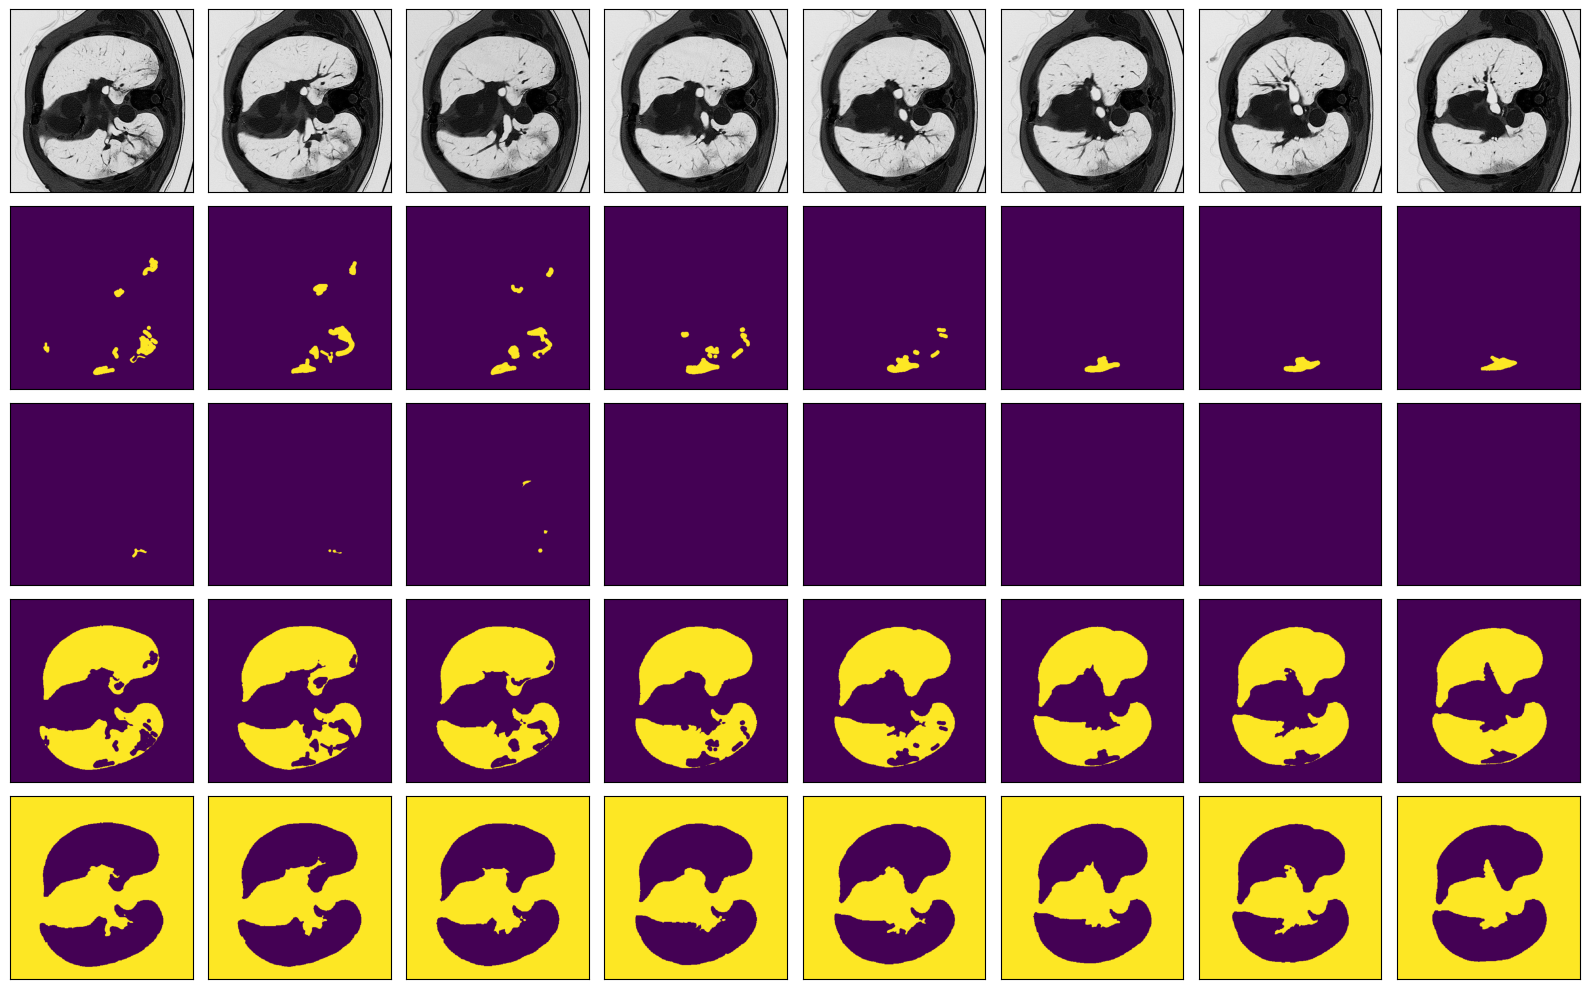

In [47]:
visualize(images_radiopedia[30:], masks_radiopedia[30:])

### Profundización en el Dataset y Visualización

El dataset combina volúmenes de **Radiopedia** y **MedSeg**, especializados en patologías pulmonares. Aquí detallamos la naturaleza de los datos:

*   **Origen de las imágenes:** Las imágenes provienen de casos reales recopilados por Radiopaedia.org y la plataforma MedSeg. Estos volúmenes fueron anotados por radiólogos expertos para identificar hallazgos específicos de COVID-19. Los datos originales en formato NIfTI (3D) se convirtieron a cortes 2D (slices) almacenados en archivos `.npy` para optimizar el entrenamiento en deep learning.
*   **Naturaleza de las imágenes (CT Scans):** Las imágenes son cortes axiales de Tomografía Computarizada. A diferencia de las fotos normales, los valores de los píxeles están en **Unidades Hounsfield (HU)**, que miden la radiodensidad. El aire tiene un valor de -1000 HU y el agua 0 HU. En este dataset, las lesiones COVID suelen encontrarse en rangos específicos que resaltamos mediante *clipping*.
*   **Detalle de las Clases (Etiquetas):**
    *   **Clase 0 - Vidrio Esmerilado (Ground Glass):** Opacidad nebulosa que no borra las estructuras bronquiales o vasculares. Es el hallazgo más común y temprano.
    *   **Clase 1 - Consolidaciones:** Aumento de densidad que sí borra los márgenes de los vasos y paredes de la vía aérea.
    *   **Clase 2 - Otros tejidos pulmonares:** Pulmón sano o con otras patologías no relevantes para esta segmentación.
    *   **Clase 3 - Fondo:** Todo lo que está fuera del parénquima pulmonar (huesos, grasa, aire externo).
*   **Detalles Técnicos:**
    *   **Resolución:** 512x512 píxeles por slice, permitiendo ver detalles finos del parénquima pulmonar.
    *   **Pre-procesamiento:** Se ha aplicado una normalización estadística (Z-score) tras limitar el rango de HU entre -1500 y 500 para eliminar el ruido de tejidos densos (huesos) o artefactos externos.
*   **Visualización Multicanal:** La función `visualize` permite comparar el scan original con las máscaras. En las visualizaciones de predicción, el canal **Verde** representa el área real (Ground Truth) y el **Rojo** la predicción del modelo; las zonas donde ambos coinciden se ven en tonos **Amarillos/Anaranjados**, facilitando la identificación de errores de segmentación.

Hot encoded mask size:  (829, 512, 512, 4)
Paletted mask size: (100, 512, 512)


IndexError: too many indices for array: array is 3-dimensional, but 4 were indexed

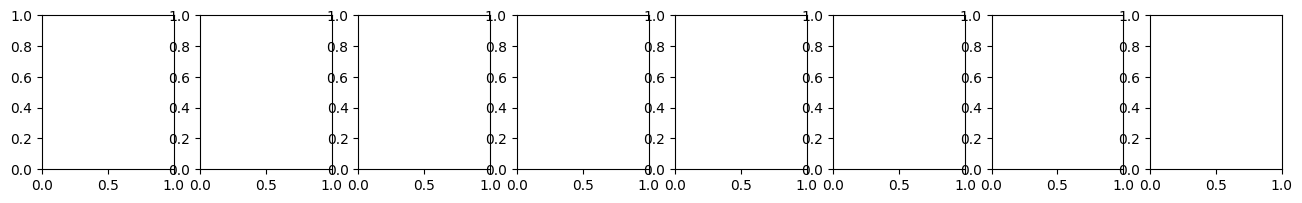

In [48]:
palette = [[0], [1], [2],[3]]
masks_radiopedia_recover = onehot_to_mask(masks_radiopedia, palette).squeeze()  # shape = (H, W)

masks_medseg_recover = onehot_to_mask(masks_medseg, palette).squeeze()  # shape = (H, W)

print('Hot encoded mask size: ',masks_radiopedia.shape)
print('Paletted mask size:',masks_medseg_recover.shape)

visualize(masks_medseg_recover[30:],hot_encode=False)

## Preprocess images:

In [ ]:
images_radiopedia, mean_std = preprocess_images(images_radiopedia)
images_medseg, _ = preprocess_images(images_medseg, mean_std)
test_images_medseg, _ = preprocess_images(test_images_medseg, mean_std)

In [ ]:
plot_hists(test_images_medseg, images_radiopedia)

## Split/Train

In [ ]:
masks_radiopedia_recover = onehot_to_mask(masks_radiopedia, palette).squeeze()  # shape = (H, W)
masks_medseg_recover     = onehot_to_mask(masks_medseg, palette).squeeze()  # shape = (H, W)

val_indexes, train_indexes = list(range(24)), list(range(24, 100))

train_images = np.concatenate((images_medseg[train_indexes], images_radiopedia))
train_masks  = np.concatenate((masks_medseg_recover[train_indexes], masks_radiopedia_recover))
val_images   = images_medseg[val_indexes]
val_masks    = masks_medseg_recover[val_indexes]

batch_size = len(val_masks)

del masks_medseg_recover
del masks_radiopedia_recover
del images_radiopedia
del masks_radiopedia
del images_medseg
del masks_medseg

# Prueba con gemini

In [ ]:
import torch
import numpy as np

# --- 1. Análisis de Contenido del Dataset ---
# Según la descripción, buscamos segmentar:
# Clase 0: Ground-glass
# Clase 1: Consolidation
# (El dataset original usa 4 clases, nos enfocamos en las primeras dos para el diagnóstico)

def analyze_mask_distribution(masks):
    """
    Analiza cuántos píxeles pertenecen a cada clase para entender el desbalanceo.
    """
    total_pixels = masks.size
    unique, counts = np.unique(masks, return_counts=True)
    print("--- Análisis de Clases en Máscaras ---")
    for u, c in zip(unique, counts):
        percentage = (c / total_pixels) * 100
        label = {0: 'Ground-glass', 1: 'Consolidation', 2: 'Other Lungs', 3: 'Background'}.get(u, 'Unknown')
        print(f"Clase {u} ({label}): {c} píxeles ({percentage:.2f}%)")

# Analizamos una muestra de las máscaras de entrenamiento
analyze_mask_distribution(val_masks)

# --- 2. Implementación de Métrica F1 (Dice Score) ---
# En segmentación, el F1-Score es equivalente al Dice Coefficient.
# Mide el solapamiento: (2 * Intersección) / (Suma de Áreas)

def f1_score_dice(pred_mask, mask, n_classes=2, smooth=1e-6):
    """
    Calcula el F1-score (Dice) para las clases de interés (0 y 1).
    """
    with torch.no_grad():
        pred_mask = torch.softmax(pred_mask, dim=1)
        pred_mask = torch.argmax(pred_mask, dim=1)

        f1_per_class = []
        # Solo calculamos para las clases que pide el challenge (0 y 1)
        for clas in range(n_classes):
            true_positives = torch.logical_and(pred_mask == clas, mask == clas).sum().float().item()
            false_positives = torch.logical_and(pred_mask == clas, mask != clas).sum().float().item()
            false_negatives = torch.logical_and(pred_mask != clas, mask == clas).sum().float().item()

            dice = (2 * true_positives + smooth) / (2 * true_positives + false_positives + false_negatives + smooth)
            f1_per_class.append(dice)

    return np.mean(f1_per_class)

# --- 3. Nota sobre la Solución ---
# El modelo Unet con EfficientNet-B2 que ya tienes es una excelente elección (SoTA).
# Para mejorar el F1, podrías cambiar la función de pérdida a 'DiceLoss' o 'ComboLoss'
# (Dice + CrossEntropy) para forzar al modelo a optimizar el solapamiento directamente.

print("\n[INFO] Métrica F1 y análisis listos. Puedes integrar f1_score_dice en tu función fit().")

## Documentación de la Estrategia de Segmentación

### 1. Análisis del Dataset y Desbalanceo
El conjunto de datos presenta un desbalanceo de clases significativo, típico en imágenes médicas:
* **Ground-glass (4.26%)** y **Consolidation (3.38%)**: Son las áreas de interés patológico. Su baja presencia relativa hace que la precisión (accuracy) no sea una métrica fiable, ya que un modelo que prediga todo como 'fondo' tendría >90% de precisión pero sería inútil.
* **Fondo y otros tejidos (>92%)**: Dominan el volumen de datos.

### 2. Métrica: F1-Score (Dice Coefficient)
Se seleccionó el **Dice Score** como métrica primaria porque:
* Penaliza los falsos positivos y falsos negativos de manera equilibrada.
* Es insensible al dominio de la clase de fondo, enfocándose exclusivamente en el solapamiento entre la predicción y la máscara real de las lesiones COVID.
* La implementación promedia el desempeño específicamente sobre las clases 0 y 1.

### 3. Arquitectura del Modelo
Se utiliza una **U-Net** con un codificador (encoder) **EfficientNet-B2** pre-entrenado en ImageNet:
* **Ventaja**: EfficientNet ofrece un excelente balance entre eficiencia computacional y capacidad de extracción de características.
* **Configuración**: El modelo recibe 1 canal (escala de grises de CT) y produce 4 canales de salida (uno por clase).

### 4. Estrategia de Entrenamiento
* **Pérdida**: CrossEntropyLoss (inicial). Se recomienda considerar DiceLoss si el F1 se estanca.
* **Optimizador**: AdamW con Weight Decay para prevenir el sobreajuste.
* **Scheduler**: OneCycleLR para permitir tasas de aprendizaje agresivas al inicio y finas al final, acelerando la convergencia.


## Data generator and augmentations

In [ ]:
SOURCE_SIZE = 512
TARGET_SIZE = 256

train_augs = albumentations.Compose([
    albumentations.Rotate(limit=360, p=0.9, border_mode=cv2.BORDER_REPLICATE),
    albumentations.RandomSizedCrop((int(SOURCE_SIZE * 0.75), SOURCE_SIZE),
                                   (TARGET_SIZE, TARGET_SIZE),
                                   interpolation=cv2.INTER_NEAREST),
    albumentations.HorizontalFlip(p=0.5),

])

val_augs = albumentations.Compose([
    albumentations.Resize(TARGET_SIZE, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)
])

In [ ]:
train_dataset    = Dataset(train_images, train_masks, train_augs)
val_dataset      = Dataset(val_images, val_masks, val_augs)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 5. Arquitectura del Modelo: U-Net + EfficientNet
Definimos una red neuronal convolucional tipo U-Net con un codificador pre-entrenado `efficientnet-b2`, ideal para extraer características complejas con pocos datos.


In [ ]:
i,train_data     = next(enumerate(train_dataloader))
mask_hot_encoded = mask_to_onehot(torch.unsqueeze(train_data[1],-1).numpy(),palette)
visualize(train_data[0].permute(0, 2, 3,1),mask_hot_encoded)

In [ ]:
model = smp.Unet('efficientnet-b2',in_channels=1, encoder_weights='imagenet',classes=4, activation=None, encoder_depth=5, decoder_channels=[256, 128, 64, 32, 16])

# 6. Entrenamiento y Métrica F1 (Dice Coefficient)
Ejecutamos el entrenamiento monitoreando el solapamiento (F1-Score) entre la predicción y la realidad. Guardamos automáticamente el modelo que mejor reconozca las lesiones COVID.


In [ ]:
max_lr       = 1e-2
epoch        = 10
weight_decay = 1e-3

# Definimos criterio y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
sched     = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epoch,
                                            steps_per_epoch=len(train_dataloader))

# Nota: Si el entrenamiento se interrumpe o da error, asegúrate de que
# las funciones fit y f1_score_dice estén definidas en celdas anteriores.
history = fit(epoch, model, train_dataloader, val_dataloader, criterion, optimizer, sched)

# Graficamos los resultados para validar la convergencia del F1
plot_f1(history)
plot_loss(history)

# 7. Inferencia y Generación de Resultados
Visualizamos las predicciones del modelo sobre el set de prueba y exportamos los resultados finales al formato CSV requerido para la competencia.


In [ ]:
torch.save(model, 'Unet-efficientnet.pt')

In [ ]:
plot_loss(history)
plot_score(history)
plot_acc(history)

In [ ]:
def plot_f1(history):
    if 'val_f1' in history:
        plt.figure(figsize=(8, 5))
        plt.plot(history['val_f1'], label='Val F1-Score (Dice)', color='green', marker='P')
        plt.title('Métrica F1 (Ground-glass + Consolidation) por Época')
        plt.ylabel('F1 Score')
        plt.xlabel('Epoch')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("No hay datos de F1 en el historial. Asegúrate de volver a entrenar con la nueva función fit.")

# Visualizamos la nueva métrica
plot_f1(history)

## Evaluation

### Result

In [ ]:
image, mask             = next(iter(val_dataloader))
pred_mask, score,output = predict_image_mask_miou(model, image, mask)
semantic_map            = mask_to_onehot(torch.unsqueeze(mask,-1).numpy(),palette)

In [ ]:
visualize(image.cpu(), semantic_map, pred_batch=output.cpu())

In [ ]:
mob_miou = miou_score(model, val_dataloader)
mob_miou

In [ ]:
del train_images
del train_masks

## Test preds:

In [ ]:
image_batch = np.stack([val_augs(image=img)['image'] for img in test_images_medseg], axis=0)
print(torch.from_numpy(image_batch).shape)
print(image_batch[i].shape)
#output = test_predict(model, torch.from_numpy(image_batch).permute(0, 3, 1,2))
output = np.zeros((10,256,256,4))
for i in range(10):
    output[i] = test_predict(model, image_batch[i]).cpu().numpy()
print(output.shape)
test_masks_prediction = output > 0.5
visualize(image_batch, test_masks_prediction, num_samples=len(test_images_medseg))

## Resize prediction to original size

In [ ]:
test_masks_prediction_original_size = scipy.ndimage.zoom(test_masks_prediction[..., :-2], (1, 2, 2, 1), order=0)
test_masks_prediction_original_size.shape

In [ ]:
pd.DataFrame(
             data=np.stack((np.arange(len(test_masks_prediction_original_size.ravel())),
                            test_masks_prediction_original_size.ravel().astype(int)),
                            axis=-1),
             columns=['Id', 'Predicted'])\
.set_index('Id').to_csv('sub.csv')